# 🧪 Fine-Tuning & Adaptation

Fine-tuning allows you to **customize a pre-trained LLM** 🧠 for a specific domain,  
task, or style using specialized datasets. It helps models perform better  
on narrow tasks where **base models may lack context**.


### 🚀 Example

Imagine you have an **AI insurance advisor** that helps you find the best insurance plans. At first, the AI knows general things about all kinds of insurance: car 🚗, home 🏠, life 💖, health 🏥, etc.

One day, you ask it, “What’s the best home insurance for me?”  
It gives you a general answer, but it doesn’t consider your **specific needs**—like the fact that you live in a **flood zone** 🌊 or have a **vintage car** 🚙. The answer isn’t perfect.

So, you provide the AI with some **feedback**:  
“Please focus on plans that cover **flood damage** and **valuable items**.”

---

### ✨ **Fine-Tuning the AI**  
The AI now **fine-tunes** its knowledge by learning more about **flood-prone homes** and **vintage cars**. It reviews **specialized data** on:
- Flood coverage 🌊  
- Insurance plans for valuable items 💎

After a few updates, when you ask the same question again, it gives you a **better, tailored answer**:  
“Here’s a home insurance plan that covers **flood damage** and provides extra protection for your **vintage items** like antiques.”

---

### 🎯 **The Result:**
The AI was **fine-tuned** to focus on your **specific needs**. It’s now like having an expert who understands your situation and gives you the **best recommendations** every time!

---

### **In short**:  
Fine-tuning in insurance is like teaching an AI to focus on what matters most to YOU, making it more **accurate** and **useful** over time! 🔍💡

---

 🎯 Learning Objectives
- Instruction Fine-Tuning (SFT)
- Efficient Fine-Tuning (LoRA / QLoRA)
- Popular datasets: Alpaca, Dolly
- Key libraries: `transformers`, `trl`, `peft`
- Safety & evaluation after fine-tuning


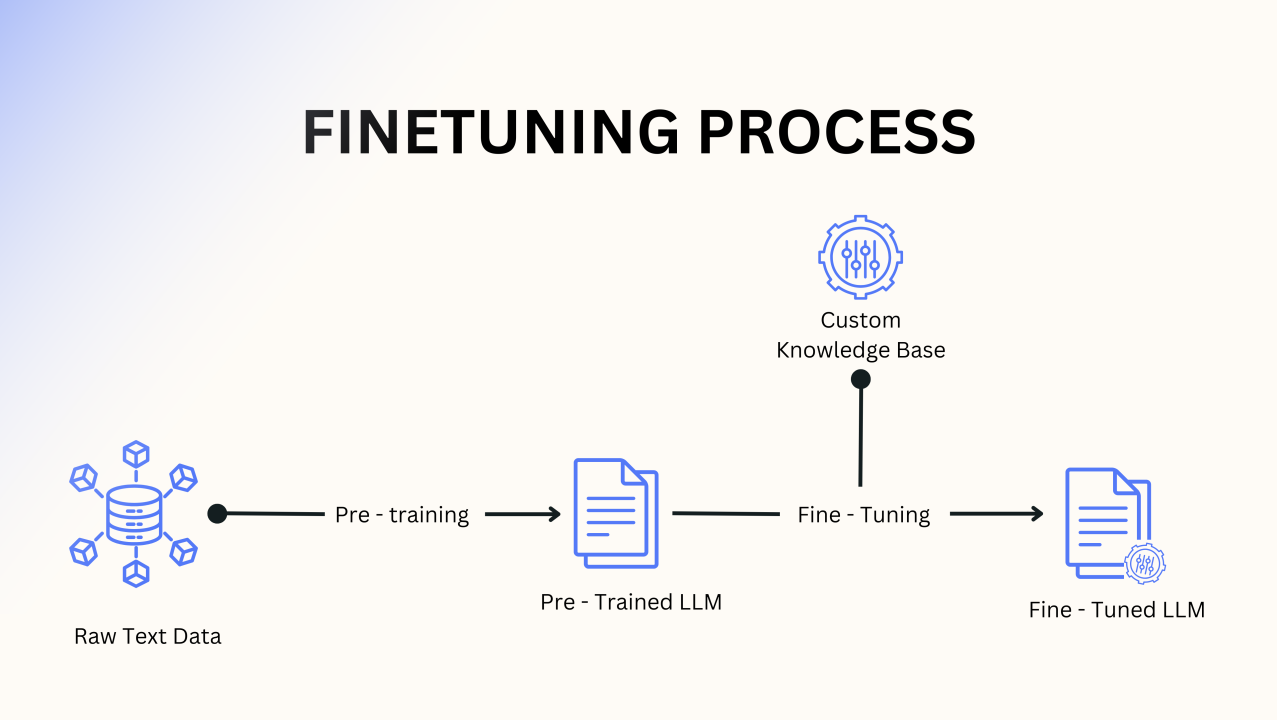

In [2]:
from IPython.display import Image

Image(filename='data/fine_tunning.png')


```markdown
 Fine-Tuning Theory (LLMs & Microsoft Approach)

 What is Fine-Tuning?
Fine-tuning adapts a pre-trained large language model (such as GPT-3, GPT-4, or Azure OpenAI’s models) to perform better on a custom dataset or a specific task. This allows organizations to tailor LLMs to their industry language, workflows, or customer needs.

 Microsoft Azure OpenAI Fine-Tuning Overview
- Azure OpenAI Service provides enterprise access to powerful LLMs (like GPT-3, GPT-4) and supports model customization via fine-tuning.
- You upload an instruction and completion dataset (JSONL format), and Azure handles the training for you.
- Typical use cases: chatbots, summarization, scenario-specific Q&A, code generation, etc.
```

```markdown
 Example: Fine-Tuning Using Azure OpenAI Service

Below is a simplified workflow and sample code using Microsoft’s Azure OpenAI Python SDK.

_Note: Actual fine-tuning on Azure is performed via REST APIs or Azure CLI. Students need Azure access credentials for real runs. The following code demonstrates the setup steps and is illustrative:_
```

```python
 Install the Azure OpenAI SDK first if needed
 %pip install azure-ai-openai

from azure.ai.openai import OpenAIClient
from azure.identity import DefaultAzureCredential

 Authenticate (make sure your Azure account is configured)
credential = DefaultAzureCredential()
client = OpenAIClient(endpoint="https://YOUR_RESOURCE_NAME.openai.azure.com/", credential=credential)

 Upload your training data, e.g., 'training_data.jsonl'
response = client.begin_create_fine_tuning_job(
    training_file="training_data.jsonl",
    model="gpt-35-turbo",        Specify your base model
    suffix="my-finetuned-model"
)
print("Fine-tuning job started:", response.status())
```

```markdown
 Dataset Format Example (JSONL)

Your data should look like this (`training_data.jsonl`):

```
{"prompt": "Translate to French: 'Hello, world!'", "completion": "Bonjour le monde!"}
{"prompt": "Classify sentiment: 'I love this!'", "completion": "positive"}
```

---

🔒 *Tip*: Real fine-tuning happens on the cloud; make sure data is high-quality and formatted cleanly for best results.
```


 Fine-Tuning with Large Language Models (LLMs)
 In this notebook, we will learn what fine-tuning is and how it works with LLMs like GPT.

 What is Fine-Tuning?

 Fine-tuning is a process in machine learning where we take a pre-trained model 
 (like GPT-3 or GPT-4) and adapt it to perform better on specific tasks.
 Think of it as teaching an already smart student (the pre-trained model) 
 to become even better at something specific by giving them more focused lessons.

 Why do we need Fine-Tuning?

 Large Language Models (LLMs) are trained on massive amounts of data 
 from the internet, but they aren't always perfect for every task. 
 Fine-tuning helps improve their performance on specific tasks or domains.

 Example: Fine-Tuning GPT-3

 Suppose we want to use GPT-3 to write emails. 
 The model might be good at generating text, but it may not have the best email-writing style.
 So, we would fine-tune it on a dataset of good email examples to teach it the right tone and style.

 Let's break down the steps involved in fine-tuning with LLMs:

 Step 1: Choose a Pre-trained Model
 We start with a pre-trained model, like GPT-3 or GPT-4. These models are already trained on large datasets 
 and can generate high-quality text for a wide range of tasks.

 Step 2: Prepare a Dataset
 Fine-tuning requires a dataset that is related to the specific task or domain you want the model to perform well on. 
 For example, if we want GPT-3 to write emails, we gather a collection of good email examples.

 Step 3: Fine-Tune the Model
 Using the dataset, we adjust the model's parameters to make it better at the task. 
 Fine-tuning can be done using machine learning libraries like Hugging Face or OpenAI's API.

 Step 4: Evaluate the Model
 After fine-tuning, we test the model's performance by asking it to generate text in the specific task area. 
 For example, we ask it to write an email and check if it's doing well.

 Key Points:
 - Fine-tuning makes a pre-trained model better at a specific task.
 - You use a dataset related to the task to teach the model.
 - Fine-tuning can be done using machine learning frameworks like Hugging Face or OpenAI.

 Example Code: Fine-Tuning GPT-3 Using OpenAI API

 Here's a simple example of how you would fine-tune GPT-3 for a specific task using the OpenAI API.

 1. First, you need to prepare your dataset (e.g., a set of labeled emails).
 2. Use OpenAI's API to fine-tune the model.

import openai

openai.api_key = "your-openai-api-key"

 Step 1: Create a fine-tuning job with a dataset
 You need to upload your fine-tuning dataset to OpenAI

response = openai.File.create(
  file=open("fine_tuning_dataset.jsonl"),
  purpose='fine-tune'
)

 Step 2: Fine-tune the model
fine_tuned_model = openai.FineTune.create(
  training_file=response['id'],
  model="curie",   Choose a pre-trained model
)

 Step 3: Use the fine-tuned model for generating text
generated_email = openai.Completion.create(
  model=fine_tuned_model['id'],
  prompt="Write an email to a customer thanking them for their purchase.",
  max_tokens=150
)

print(generated_email.choices[0].text.strip())

 This code shows the process of fine-tuning GPT-3 with a custom dataset (in this case, emails) 
 and then using the fine-tuned model to generate emails based on a prompt.

 Conclusion

 Fine-tuning allows us to take a general-purpose LLM and make it better suited for a particular task. 
 It's like giving the model more practice to master a specific skill. Fine-tuning is crucial for 
 achieving better performance when working with specialized tasks like email generation, 
 medical text analysis, customer support, and more!
